¡Éxito! Primeras filas del dataset cargado desde Google Drive:


,CODIGO_ACCIDENTE,GRAVEDAD,CLASE,CODIGO_LOCALIDAD,DISENO_LUGAR
195041,10529303,3,1,10,1
3800,4405490,3,1,2,1
76624,4479538,3,1,1,1
10444,4412037,3,1,11,1
13912,4415672,3,1,8,1



Precisión del modelo (Accuracy): 84.67%


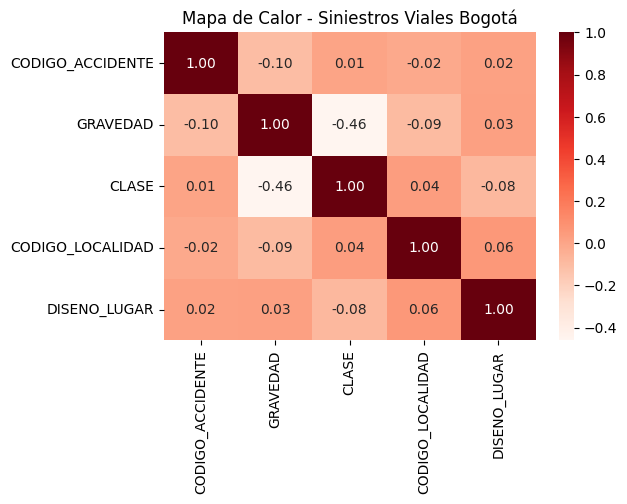

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Ruta exacta donde está tu archivo en Google Drive dentro de Colab
excel_path = '/content/drive/MyDrive/Colab Notebooks/siniestros_viales_consolidados_bogota_dc(1).xlsx'

# Cargar el archivo Excel oficial de Bogotá
df_excel = pd.read_excel(excel_path, sheet_name='SINIESTROS')

# Extraer una muestra limpia de 500 filas con las columnas clave
df_sample = df_excel[['CODIGO_ACCIDENTE', 'GRAVEDAD', 'CLASE', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR']].sample(n=500, random_state=42).dropna()

print("¡Éxito! Primeras filas del dataset cargado desde Google Drive:")
display(df_sample.head())

# Entrenar el modelo de clasificación (Árbol de Decisión)
X = df_sample[['CLASE', 'CODIGO_LOCALIDAD', 'DISENO_LUGAR']]
y = df_sample['GRAVEDAD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo.fit(X_train, y_train)

predicciones = modelo.predict(X_test)
print(f"\nPrecisión del modelo (Accuracy): {accuracy_score(y_test, predicciones) * 100:.2f}%")

# Generar y mostrar el mapa de calor
plt.figure(figsize=(6, 4))
sns.heatmap(df_sample.corr(numeric_only=True), annot=True, cmap='Reds', fmt=".2f")
plt.title("Mapa de Calor - Siniestros Viales Bogotá")
plt.show()